<a href="https://colab.research.google.com/github/fdhliakbar/IR-Lab/blob/main/P10_Collaborative_Filtering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Collborative Filtering

`Content-based filtering` adalah salah satu pendekatan yang digunakan dalam sistem rekomendasi (recommender system) untuk memberikan saran kepada pengguna berdasarkan kesamaan antara karakteristik item dan preferensi pengguna. Pendekatan ini fokus pada analisis dan pemahaman atribut atau fitur dari item yang direkomendasikan serta profil pengguna, dengan tujuan menemukan item yang mirip dengan yang sudah disukai pengguna sebelumnya.

### Prinsip Dasar

`Content-Based Filtering` Pada intinya, sistem `content-based filtering` bekerja dengan memodelkan preferensi pengguna berdasarkan item-item yang telah mereka pilih, nilai, atau interaksikan di masa lalu. Model ini kemudian merekomendasikan item lain yang memiliki kemiripan fitur dengan item yang disukai oleh pengguna tersebut.

### Contoh

<img src="https://th.bing.com/th/id/R.ef0c39ef2786273be02e7539953bfb5c?rik=S3kFifgMCeoUBg&riu=http%3a%2f%2fwww.clungu.com%2fassets%2fimages%2f2018-10-18-Building_a_recommender_system_files%2fcontent-based-filtering.png&ehk=NAvpPEJSo%2biqzCPMXQTcJeoyNSHjaTKqHX4WcYkDsP4%3d&risl=&pid=ImgRaw&r=0" alt="content based filtering example"/>

Jika seorang pengguna sering menonton `film bergenre aksi`, sistem akan merekomendasikan lebih banyak film aksi karena genre tersebut telah menjadi bagian dari preferensi pengguna yang diketahui.

Teknik dalam Content-Based Filtering
Beberapa teknik yang digunakan untuk melakukan analisis fitur dan membuat rekomendasi:

1. TF-IDF (`Term Frequency-Inverse Document Frequency`): Digunakan dalam pemrosesan teks untuk mewakili item (misalnya, dokumen atau artikel) sebagai vektor yang berdasarkan pada seberapa sering kata tertentu muncul dalam dokumen (term frequency) dan seberapa jarang kata tersebut muncul di keseluruhan kumpulan dokumen (inverse document frequency).
2.	`Cosine Similarity`: Salah satu metode yang sering digunakan untuk mengukur kemiripan antara dua vektor (misalnya, vektor fitur dari item atau vektor profil pengguna) dengan menghitung sudut kosinus antara vektor tersebut.
3.	`K-Nearest Neighbors`: Algoritma yang dapat digunakan untuk menemukan item-item yang paling mirip dengan item favorit pengguna berdasarkan fitur mereka.
4. `SVD`: Memecah matriks rating menjadi faktor laten (tersembunyi) untuk menemukan pola tersembunyi dalam data


### Contoh lainnya

1.	**Spotify**: Menggunakan content-based filtering untuk merekomendasikan musik berdasarkan genre, artis, atau lagu yang sering didengarkan oleh pengguna.
2.	**Netflix**: Menggunakan fitur seperti genre film, pemeran, atau sutradara untuk merekomendasikan film yang mirip dengan film yang telah ditonton oleh pengguna.
3.	**Amazon**: Menyediakan rekomendasi produk berdasarkan karakteristik produk yang sering dibeli atau dilihat oleh pengguna.

---


## Lanjut Langkah Praktikum😺

### Installasi & import library

In [1]:
!pip install surprise
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from surprise import SVD
from surprise import accuracy
from surprise import Dataset
from surprise import Reader
from surprise import KNNBasic
from surprise.model_selection import train_test_split

In [2]:
rating = pd.read_csv("/content/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products - Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv")

In [3]:
rating.head()

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.dateSeen,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,"2018-05-27T00:00:00Z,2017-09-18T00:00:00Z,2017...",False,NaN,0,3,http://reviews.bestbuy.com/3545/5442403/review...,I thought it would be as big as small paper bu...,Too small,llyyue,https://www.newegg.com/Product/Product.aspx%25...
1,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,"2018-05-27T00:00:00Z,2017-07-07T00:00:00Z,2017...",True,NaN,0,5,http://reviews.bestbuy.com/3545/5442403/review...,This kindle is light and easy to use especiall...,Great light reader. Easy to use at the beach,Charmi,https://www.newegg.com/Product/Product.aspx%25...
2,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,2018-05-27T00:00:00Z,True,NaN,0,4,https://reviews.bestbuy.com/3545/5442403/revie...,Didnt know how much i'd use a kindle so went f...,Great for the price,johnnyjojojo,https://www.newegg.com/Product/Product.aspx%25...
3,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,2018-10-09T00:00:00Z,True,177283626.0,3,5,https://redsky.target.com/groot-domain-api/v1/...,I am 100 happy with my purchase. I caught it o...,A Great Buy,Kdperry,https://www.newegg.com/Product/Product.aspx%25...
4,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,2018-05-27T00:00:00Z,True,NaN,0,5,https://reviews.bestbuy.com/3545/5442403/revie...,Solid entry level Kindle. Great for kids. Gift...,Solid entry-level Kindle. Great for kids,Johnnyblack,https://www.newegg.com/Product/Product.aspx%25...


In [4]:
rating.describe()

rating.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   5000 non-null   object 
 1   dateAdded            5000 non-null   object 
 2   dateUpdated          5000 non-null   object 
 3   name                 5000 non-null   object 
 4   asins                5000 non-null   object 
 5   brand                5000 non-null   object 
 6   categories           5000 non-null   object 
 7   primaryCategories    5000 non-null   object 
 8   imageURLs            5000 non-null   object 
 9   keys                 5000 non-null   object 
 10  manufacturer         5000 non-null   object 
 11  manufacturerNumber   5000 non-null   object 
 12  reviews.date         5000 non-null   object 
 13  reviews.dateAdded    1052 non-null   object 
 14  reviews.dateSeen     5000 non-null   object 
 15  reviews.doRecommend  5000 non-null   b

### Exploratory Data Analysis (EDA)

Menganalisis dan memvisualisasikan data untuk mendapatkan wawasan beserta memahami distribusi rating, kategori,rekomendasi

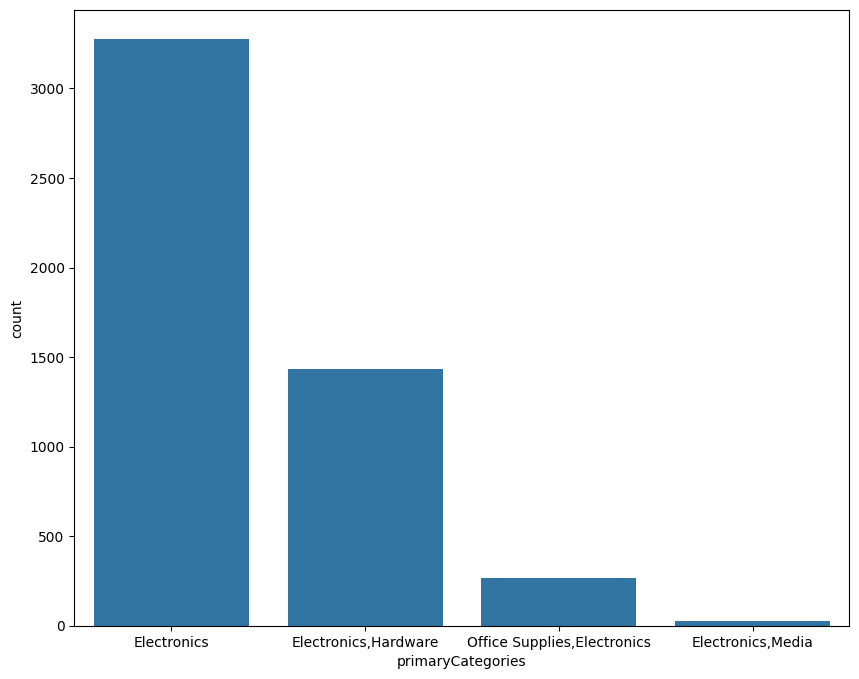

In [30]:
primary_cat = rating['primaryCategories'].value_counts()
primary_cat

dims = (10,8)
fig, ax = plt.subplots(figsize=dims)
ax = sns.countplot(x=rating.primaryCategories)

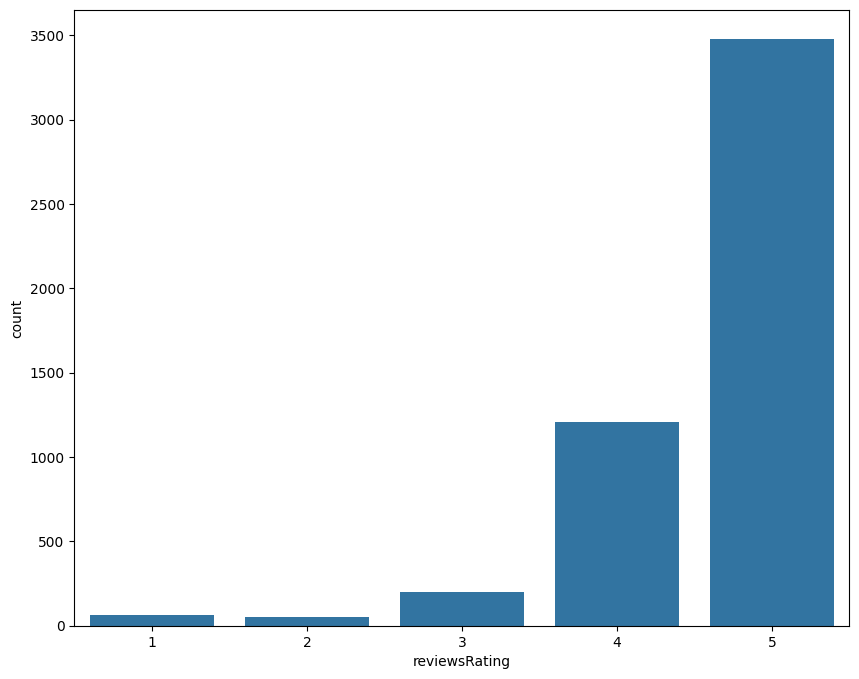

In [6]:
rating.rename(columns={"reviews.rating":"reviewsRating"}, inplace=True)

# jadikan sebagai var dan lakukan perhitungan sejumlah nilai yang ada di kolom reviewRating
rev_rating = rating['reviewsRating'].value_counts()
rev_rating

# visual
dims = (10,8)
fig, ax = plt.subplots(figsize=dims)
ax = sns.countplot(x="reviewsRating", data=rating)

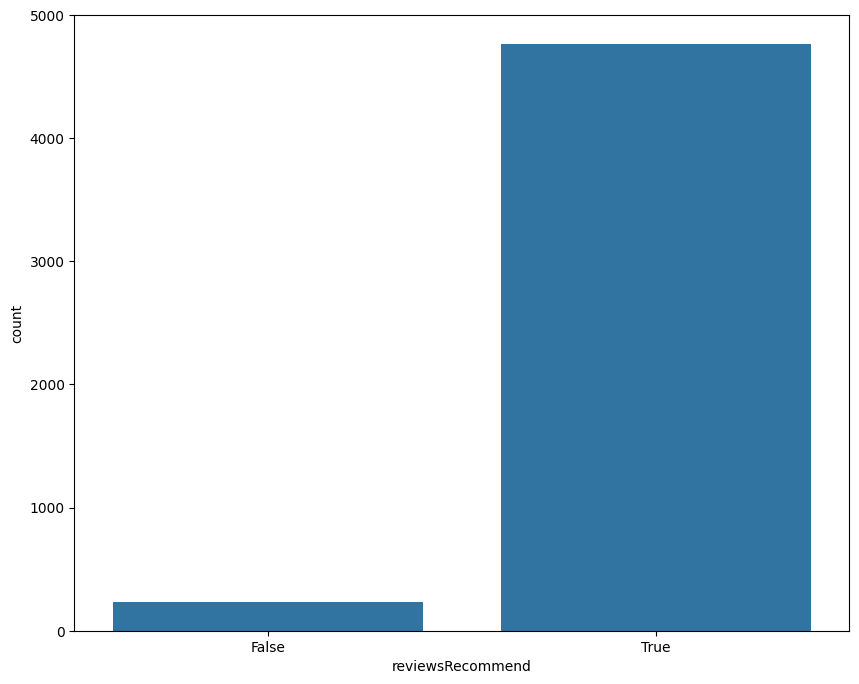

In [11]:
if 'reviews.doRecommend' in rating.columns:
    rating.rename(columns={"reviews.doRecommend":"reviewsRecommend"}, inplace=True)
elif 'reviewsDoRecommend' in rating.columns:
    rating.rename(columns={"reviewsDoRecommend":"reviewsRecommend"}, inplace=True)

rev_rec = rating['reviewsRecommend'].value_counts()
rev_rec

dims = (10,8)
fig, ax = plt.subplots(figsize=dims)
ax = sns.countplot(x="reviewsRecommend", data=rating)

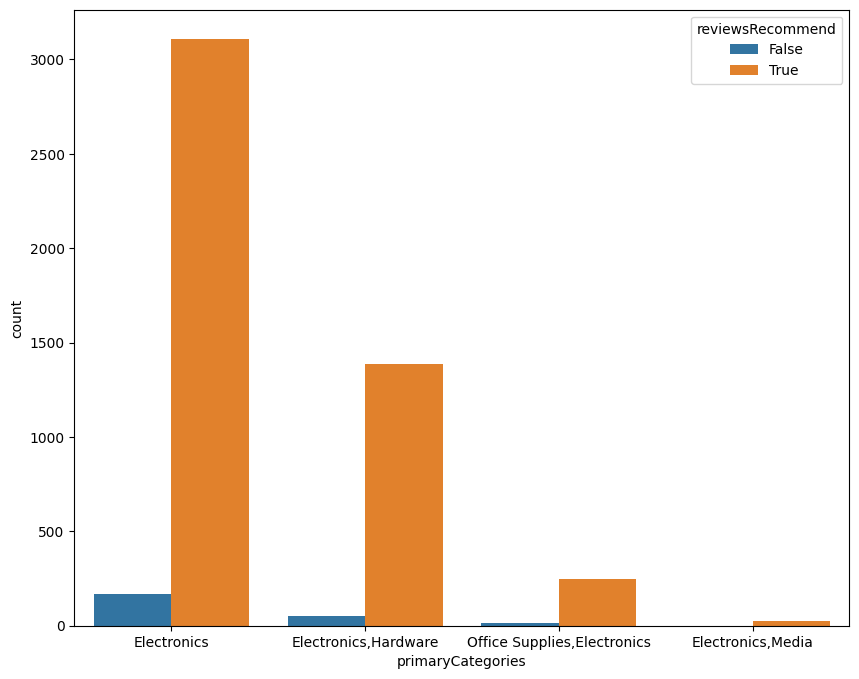

In [12]:
dims = (10,8)
fig, ax = plt.subplots(figsize=dims)
ax = sns.countplot(x="primaryCategories", hue="reviewsRecommend", data=rating)

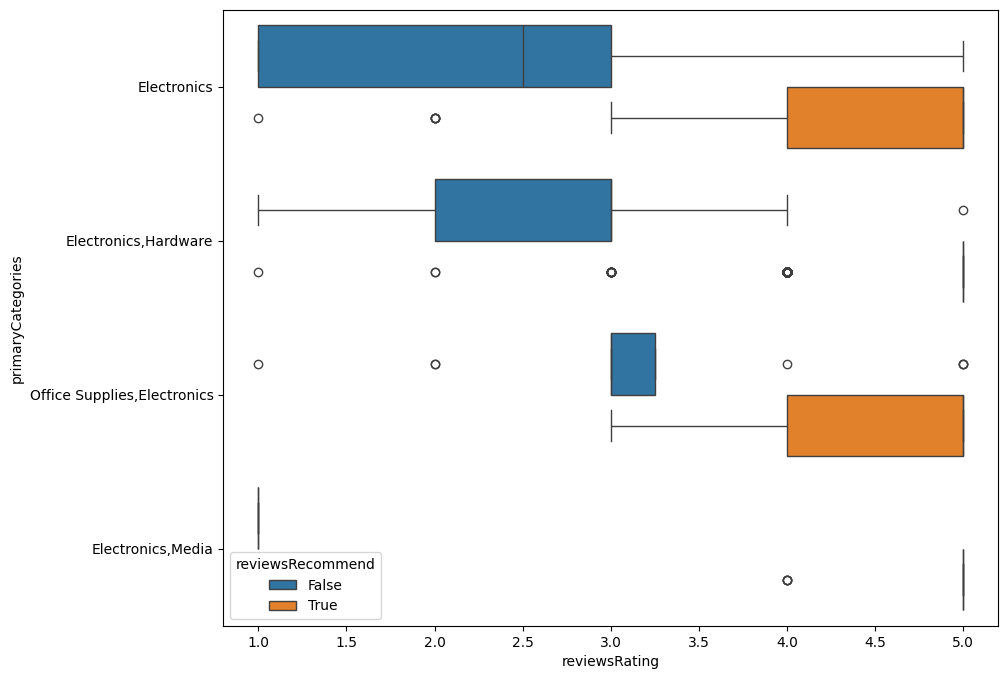

In [14]:
dims = (10,8)
fig, ax = plt.subplots(figsize=dims)
ax = sns.boxplot(x="reviewsRating", y="primaryCategories", hue="reviewsRecommend", data=rating)

### Pra-pemrosesan Data

Membersihkan dan mempersiapkan data agar sesuai dengan format yang dibutuhkan oleh library surprise.

In [15]:
# cek apakah ada yang null pada dataset
rating.isnull().sum()

,0
id,0
dateAdded,0
dateUpdated,0
name,0
asins,0
brand,0
categories,0
primaryCategories,0
imageURLs,0
keys,0


In [16]:
# dataset yg akan dipakai untuk train test split dengan framework surprise
rating[['reviews.username','id', 'reviewsRating']]

,reviews.username,id,reviewsRating
0,llyyue,AVqVGZNvQMlgsOJE6eUY,3
1,Charmi,AVqVGZNvQMlgsOJE6eUY,5
2,johnnyjojojo,AVqVGZNvQMlgsOJE6eUY,4
3,Kdperry,AVqVGZNvQMlgsOJE6eUY,5
4,Johnnyblack,AVqVGZNvQMlgsOJE6eUY,5
...,...,...,...
4995,litle,AVqkIdZiv8e3D1O-leaJ,5
4996,gracie,AVqkIdZiv8e3D1O-leaJ,5
4997,Hawk,AVqkIdZiv8e3D1O-leaJ,4
4998,Mrbilly,AVqkIdZiv8e3D1O-leaJ,5


### Data ke Format Surprise dan Membagi

Konversi dataframe dari `pandas` menjadi formatnya dataset `surprise` dan membagi menjadi `train set` dan `test set` lur

In [17]:
# definisikan format data rating. by default 1-5
reader = Reader()
data = Dataset.load_from_df(rating[['reviews.username','id', 'reviewsRating']], reader)

# train dan test
trainset, testset = train_test_split(data, test_size=0.20, random_state=50)

### Implementasi SVD (Matrix Factorization)

Kita latih model SVD pada `train set`, yg nantinya membuat prediksi pada `test set`

In [18]:
# membuat instance dari algoritma SVD
algo_svd = SVD()
predicition_mf = algo_svd.fit(trainset).test(testset)  # pelajari matriks faktor laten untuk user & item

# daftar objek prediction, pasangan pengguna(uid),item(iid),Hasil estimasi rating(r_ui)
predicition_mf

[Prediction(uid='boste03', iid='AVqkIhwDv8e3D1O-lebb', r_ui=5.0, est=4.581438673722695, details={'was_impossible': False}),
 Prediction(uid='Kevinandkalii', iid='AVqkIj9snnc1JgDc3khU', r_ui=5.0, est=4.677562996485449, details={'was_impossible': False}),
 Prediction(uid='PT53226', iid='AWFUWc8THh53nbDRF6YO', r_ui=4.0, est=4.661378647167118, details={'was_impossible': False}),
 Prediction(uid='kimb', iid='AVpgdkC8ilAPnD_xsvyi', r_ui=5.0, est=4.648252654086467, details={'was_impossible': False}),
 Prediction(uid='Colleen', iid='AVph0EeEilAPnD_x9myq', r_ui=5.0, est=4.628951663289825, details={'was_impossible': False}),
 Prediction(uid='Lintor', iid='AWFUWc8THh53nbDRF6YO', r_ui=5.0, est=4.661378647167118, details={'was_impossible': False}),
 Prediction(uid='Jays', iid='AVpgdkC8ilAPnD_xsvyi', r_ui=5.0, est=4.491701006854134, details={'was_impossible': False}),
 Prediction(uid='Squirl', iid='AWK8z0pOIwln0LfXlSxH', r_ui=5.0, est=4.656897187711412, details={'was_impossible': False}),
 Predictio

In [19]:
recom_svd = algo_svd.predict(uid="tabman",iid="AVqkIdZiv8e3D1O-leaJ")
recom_svd

Prediction(uid='tabman', iid='AVqkIdZiv8e3D1O-leaJ', r_ui=None, est=4.582751337358424, details={'was_impossible': False})

### Implementasi K-Nearest Neighbors

Melatih model `KNN` pada `train set`, untuk membuat prediksi pada data uji

In [22]:
# konfigurasi kemiripan antar pengguna dihitung
sim_options = {'name': 'pearson_baseline','shrinkage':0}
algo = KNNBasic(sim_options=sim_options)
algo_knn = KNNBasic(k=50, sim_options=sim_options) # k=50 pengguna
prediction_kkn = algo_knn.fit(trainset).test(testset)


prediction_kkn

Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.


[Prediction(uid='boste03', iid='AVqkIhwDv8e3D1O-lebb', r_ui=5.0, est=4.60925, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'}),
 Prediction(uid='Kevinandkalii', iid='AVqkIj9snnc1JgDc3khU', r_ui=5.0, est=5, details={'actual_k': 3, 'was_impossible': False}),
 Prediction(uid='PT53226', iid='AWFUWc8THh53nbDRF6YO', r_ui=4.0, est=4.60925, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'}),
 Prediction(uid='kimb', iid='AVpgdkC8ilAPnD_xsvyi', r_ui=5.0, est=4.946977157104646, details={'actual_k': 8, 'was_impossible': False}),
 Prediction(uid='Colleen', iid='AVph0EeEilAPnD_x9myq', r_ui=5.0, est=4.60925, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'}),
 Prediction(uid='Lintor', iid='AWFUWc8THh53nbDRF6YO', r_ui=5.0, est=4.60925, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'}),
 Prediction(uid='Jays', iid='AVpgdkC8ilAPnD_xsvyi', r_ui=5.0, est=4.60925, details={'was_impossible': True, 'reason'

In [24]:
# prediksi tunggal menggunakan KNN
recom_knn = algo_knn.predict(uid='Trentendo', iid='AWFUWc8THh53nbDRF6YO')
recom_knn

Prediction(uid='Trentendo', iid='AWFUWc8THh53nbDRF6YO', r_ui=None, est=4.666666666666666, details={'actual_k': 3, 'was_impossible': False})

### Evaluasi Model

Mengukur dan membandingkan performa kedua model (SVD dan KNN) dengan metrik standar

In [26]:
accuracy.mae(predicition_mf)
accuracy.fcp(predicition_mf)
accuracy.rmse(predicition_mf)

MAE:  0.5711
FCP:  0.4311
RMSE: 0.7922


0.7922221232472494

In [29]:
accuracy.mae(prediction_kkn)
accuracy.fcp(prediction_kkn)
accuracy.rmse(prediction_kkn)

MAE:  0.5753
FCP:  0.5641
RMSE: 0.8257


0.8256951342315226

## POSTEST 10

1. kerjakan postest seperti pada langkah praktikum
2. ubah file pada langkah praktikum dengan file yang telah disediakan
3. lakukan tes rekomendasi yg berbeda sebanyak 3 kali dan tampilkan masing-masing hasil akurasi test menggunakan algoritma `Matrix Vectorization` dan `KNN` nya  
4. Tampilkan output setiap hasil prosesnya
5. Analisis dan jelaskan hasil yang didapatkan

---

`Note`: Jika ada perlu ditanyakan terkait teknis praktikum, jangan ragu bertanya. Silahkan bertanya di group atau pc dengan asisten `Fadhli` & `Aufa`

<div align="center">
<img src="https://i.pinimg.com/1200x/f7/b0/98/f7b098711e66649dfd9513b01aef1844.jpg" alt="Banner Image" />
</div>